#ANN_Composition Prediction Model

##Load Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from scipy import stats

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

##Load Dataset

In [ ]:
df = pd.read_excel("DataSetSW_ANN.xlsx")

## Choosing dependant variables using a single model

In [ ]:
# Assume these are the independent features:
features = ["GDP", "Population", "GDP/Capita", "Literacy Rate", "Urban Population %", "HH Size"]

# And these are the multiple dependent variables to predict:
target_cols = ["Organic%" , "Paper%" , "Plastic%", "Metal%", "Glass%", "E waste %"] # change the subsets of dependant variables to experiment here

X = df[features]
y = df[target_cols]

In [ ]:
print("Shape before outlier removal:", X.shape)
def remove_outliers_z(X, y, threshold=2):
    data = pd.concat([X, y], axis=1)
    z_scores = np.abs(stats.zscore(data))
    mask = (z_scores < threshold).all(axis=1)
    return data[mask][X.columns], data[mask][y.columns]

X, y = remove_outliers_z(X, y)
print("Shape after outlier removal:", X.shape)

Shape before outlier removal: (161, 6)
Shape after outlier removal: (109, 6)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scale targets separately
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [ ]:
def build_model(num_layers=2, neurons=32, activation='relu'):
    model = Sequential()
    # Input layer + first hidden layer
    model.add(Dense(neurons, activation=activation, input_shape=(X_train_scaled.shape[1],)))
    # Additional hidden layers if num_layers > 1
    for _ in range(num_layers - 1):
        model.add(Dense(neurons, activation=activation))
    # Output layer: one neuron per target variable
    model.add(Dense(len(target_cols), activation='linear'))
    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
param_grid = {
    'num_layers': [5],
    'neurons': [32],
    'activation': ['relu'] # 'tanh'
}
# param_grid = {
#     'num_layers': list(range(0, 5)),  # Layers from 2 to 12
#     'neurons': list(range(6, 18, 2)),  # Neurons from 32 to 512 with step 32
#     'activation': ['relu']
# }

best_score = -np.inf
best_params = {}
best_model = None
best_history = None

early_stop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True, verbose=0)

# Grid search with validation split during training
for num_layers in param_grid['num_layers']:
    for neurons in param_grid['neurons']:
        for activation in param_grid['activation']:
            print(f"Training model with {num_layers} layers, {neurons} neurons, activation={activation}")
            model = build_model(num_layers=num_layers, neurons=neurons, activation=activation)
            history = model.fit(X_train_scaled, y_train_scaled,
                                validation_split=0.2,
                                epochs=100,
                                batch_size=10,
                                callbacks=[early_stop],
                                verbose=0)
            # Predict on test set and inverse scale predictions
            y_pred_scaled = model.predict(X_test_scaled, verbose=0)
            y_pred = scaler_y.inverse_transform(y_pred_scaled)
            # Compute R² for each target and average them
            r2_scores = []
            for i, col in enumerate(target_cols):
                r2 = r2_score(y_test[col], y_pred[:, i])
                r2_scores.append(r2)
            avg_r2 = np.mean(r2_scores)
            print(f"Avg R2: {avg_r2:.4f} | R2 per target: {np.round(r2_scores,4)}")

            if avg_r2 > best_score:
                best_score = avg_r2
                best_params = {'num_layers': num_layers, 'neurons': neurons, 'activation': activation}
                best_model = model
                best_history = history

print("\nBest Hyperparameters:", best_params)
print("Best Average Test R2 Score:", best_score)

Training model with 5 layers, 32 neurons, activation=relu


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Avg R2: -0.1500 | R2 per target: [-0.4255 -0.0134 -0.3129  0.0024  0.0855 -0.2363]

Best Hyperparameters: {'num_layers': 5, 'neurons': 32, 'activation': 'relu'}
Best Average Test R2 Score: -0.15002829067246284


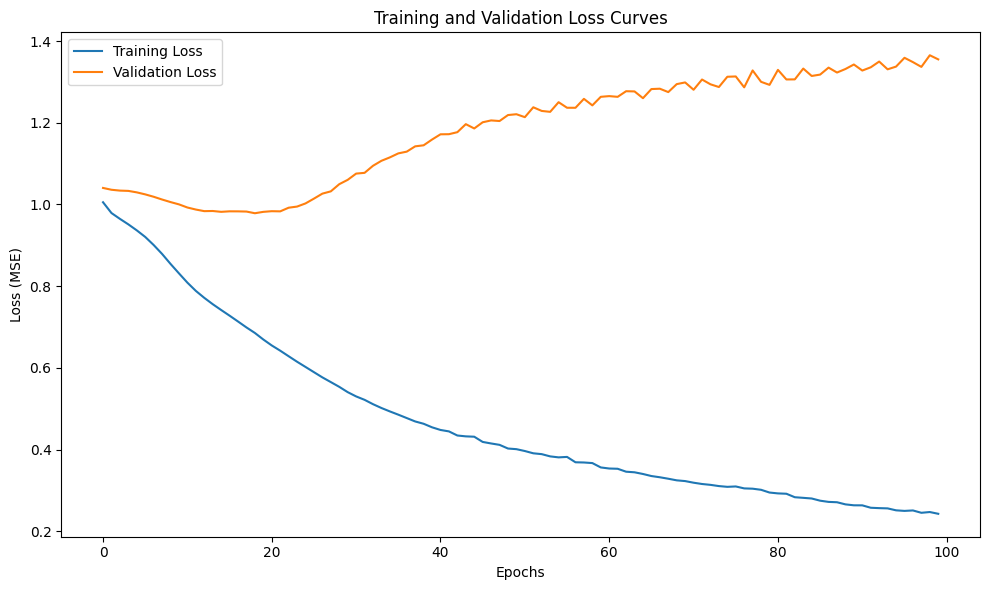

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(best_history.history['loss'], label='Training Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Evaluate the Best Model on the Test Set
y_pred_best_scaled = best_model.predict(X_test_scaled, verbose=0)
y_pred_best = scaler_y.inverse_transform(y_pred_best_scaled)

print("\nFinal R² Scores on Test Set:")
for i, col in enumerate(target_cols):
    r2 = r2_score(y_test[col], y_pred_best[:, i])
    print(f"{col}: {r2:.4f}")


Final R² Scores on Test Set:
Organic%: -0.4255
Paper%: -0.0134
Plastic%: -0.3129
Metal%: 0.0024
Glass%: 0.0855
E waste %: -0.2363


In [ ]:
import numpy as np
from random import choice
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score

# Define hyperparameter space
param_space = {
    'num_layers': list(range(2, 6)),  # Layers from 2 to 5
    'neurons': [32, 64, 128, 256, 512],  # Different neuron sizes
    'activation': ['relu', 'tanh']
}

# Number of random samples to evaluate
num_samples = 10  # Adjust as needed

best_score = -np.inf
best_params = {}
best_model = None
best_history = None

early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=0)

# Random search with validation split during training
for _ in range(num_samples):
    num_layers = choice(param_space['num_layers'])
    neurons = choice(param_space['neurons'])
    activation = choice(param_space['activation'])

    print(f"Training model with {num_layers} layers, {neurons} neurons, activation={activation}")
    model = build_model(num_layers=num_layers, neurons=neurons, activation=activation)
    history = model.fit(X_train_scaled, y_train_scaled,
                        validation_split=0.2,
                        epochs=100,
                        batch_size=10,
                        callbacks=[early_stop],
                        verbose=0)

    # Predict on test set and inverse scale predictions
    y_pred_scaled = model.predict(X_test_scaled, verbose=0)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)

    # Compute R² for each target and average them
    r2_scores = [r2_score(y_test[col], y_pred[:, i]) for i, col in enumerate(target_cols)]
    avg_r2 = np.mean(r2_scores)

    print(f"Avg R2: {avg_r2:.4f} | R2 per target: {np.round(r2_scores, 4)}")

    if avg_r2 > best_score:
        best_score = avg_r2
        best_params = {'num_layers': num_layers, 'neurons': neurons, 'activation': activation}
        best_model = model
        best_history = history

print("\nBest Hyperparameters:", best_params)
print("Best Average Test R2 Score:", best_score)


Training model with 2 layers, 512 neurons, activation=tanh


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Avg R2: 0.0316 | R2 per target: [ 0.3087  0.1926 -0.171   0.0769  0.1601 -0.3774]
Training model with 3 layers, 64 neurons, activation=tanh


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Avg R2: -0.0499 | R2 per target: [-0.0893  0.1344 -0.1295 -0.0318  0.1455 -0.3285]
Training model with 2 layers, 64 neurons, activation=relu


...

Avg R2: -0.0380 | R2 per target: [ 0.2532 -0.0683 -0.0909 -0.0412  0.0352 -0.3161]
Training model with 2 layers, 128 neurons, activation=relu


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Avg R2: -0.0537 | R2 per target: [ 0.1698 -0.1629 -0.1732 -0.0044  0.1218 -0.2733]
Training model with 5 layers, 32 neurons, activation=tanh


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Avg R2: 0.0370 | R2 per target: [ 0.3052  0.0581 -0.1618  0.1446  0.1659 -0.29  ]

Best Hyperparameters: {'num_layers': 5, 'neurons': 32, 'activation': 'tanh'}
Best Average Test R2 Score: 0.037007942741103216
